In [41]:
import mujoco
import mediapy as media
import numpy as np
from PIL import Image
from ultralytics import YOLOWorld
import matplotlib.pyplot as plt

""

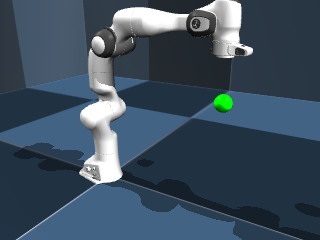

In [42]:
# Select the robot arm type, ur5e or panda
# robot_name = "ur5e"
robot_name = "panda"
xml_path = "robot/robot_arms/franka_emika_panda/scene.xml"

model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

# Reset the simulation to the initial keyframe.
mujoco.mj_resetDataKeyframe(model, data, 0)

renderer = mujoco.Renderer(model)


mujoco.mj_forward(model, data)
renderer.update_scene(data)
media.show_image(renderer.render())

# Target_id
mocap_id = model.body("target").mocapid[0]
mocap_id_reach = model.body("target_for_reach").mocapid[0]

# End-effector site we wish to control, in this case a site attached to the last
# link (wrist_3_link) of the robot.
site_id = model.site("attachment_site").id

# Cameras id
forward_cam_id = model.camera("forward_fixed_camera").id
side_cam_id = model.camera("side_fixed_camera").id

In [43]:
# Circle radius
r = 0.15
# Circle center x coordinates
cx = 0.50
# Circle centeer z cooridnates
cz = 0.50

def circle(t: float, r: float, h: float, k: float, f: float) -> np.ndarray:
    """Return the x and z coordinates of a circle with radius r centered at (h, y, k),
    where y is a variable, as a function of time t and frequency f."""
    x = r * np.cos(2 * np.pi * f * -t) + h
    y = r * np.sin(2 * np.pi * f * -t) + k
    return np.array([x, y])

def sine(t: float, A: float, f: float, phi: float) -> float:
    """Return the y coordinate of a sine wave with amplitude A, frequency f,
    and phase phi as a function of time t."""
    return A * np.sin(2 * np.pi * f * t + phi)

def cosine(t: float, A: float, f: float, phi: float) -> float:
    """Return the y coordinate of a cosine wave with amplitude A, frequency f,
    and phase phi as a function of time t."""
    return A * np.cos(2 * np.pi * f * t + phi)

In [44]:
import numpy as np
import cv2

# Utility functions for triangulation.
_GL_TO_CV = np.diag([1.0, -1.0, -1.0])

def camera_intrinsics(model, cam_id, height, width):
    """Build K from the camera's vertical FOV (MuJoCo stores fovy in DEGREES)."""
    fovy = np.deg2rad(model.cam_fovy[cam_id])
    f = (height / 2.0) / np.tan(fovy / 2.0)     # fx = fy (square pixels)
    cx = (width - 1) / 2.0
    cy = (height - 1) / 2.0
    return np.array([[f, 0, cx],
                     [0, f, cy],
                     [0, 0,  1]], dtype=np.float64)


def camera_projection(model, data, cam_id, height, width):
    """
    Full projection matrix P = K [R | t]  (world -> image) for one MuJoCo camera.

    data.cam_xmat is camera->world (the camera's pose IN the world); a projection
    matrix needs world->camera, so we transpose, then apply the GL->CV axis flip.
    """
    K = camera_intrinsics(model, cam_id, height, width)

    cam_pos = data.cam_xpos[cam_id] # camera position in world
    R_wc = data.cam_xmat[cam_id].reshape(3, 3) # camera->world rotation

    R_cw = _GL_TO_CV @ R_wc.T # world->camera
    t = -R_cw @ cam_pos # world->camera translation

    Rt = np.hstack([R_cw, t.reshape(3, 1)])
    return K @ Rt


def get_ball_position(model, data, uv1, uv2, forward_cam_id, side_cam_id,
                      height, width):
    """
    Triangulate the ball's 3D WORLD position from its pixel in two camera views.

    Args:
        uv1 : (u, v) pixel of the ball in the forward camera.
        uv2 : (u, v) pixel of the ball in the side camera.
        forward_cam_id, side_cam_id : MuJoCo camera ids.
        height, width : render resolution used to detect uv1/uv2.
                        MUST match the resolution the pixels were measured at.

    Returns:
        (3,) world-frame xyz of the ball.
    """
    P1 = camera_projection(model, data, forward_cam_id, height, width)
    P2 = camera_projection(model, data, side_cam_id, height, width)

    pts1 = np.array([[uv1[0]], [uv1[1]]], dtype=np.float64) # 2x1
    pts2 = np.array([[uv2[0]], [uv2[1]]], dtype=np.float64)

    Xh = cv2.triangulatePoints(P1, P2, pts1, pts2)
    Xh = Xh.ravel()
    return Xh[:3] / Xh[3]


# H, W = 240, 320   
# ball_xyz = get_ball_position(model, data, uv1, uv2, forward_cam_id, side_cam_id, H, W)
# data.mocap_pos[target_id] = ball_xyz

In [45]:
# Load YOLOWorld model - text-conditioned object detection model.

yolo = YOLOWorld('yolo_world/yolov8s-worldv2.pt')
yolo.set_classes(["green ball"])

# Move model to GPU
yolo.to("mps")
# yolo.to("cuda")
# yolo.to("cpu")

# Set the confidence threshold
confidence_threshold = 0.1

In [47]:
duration = 12 # (seconds)
framerate = 30  # (Hz)

# Simulate and display video.
side_view_frames = []
front_view_frames = []

# Reset the simulation to the initial keyframe.
mujoco.mj_resetDataKeyframe(model, data, 0)
mujoco.mj_forward(model, data)

 # Pre-allocate numpy arrays.
jac = np.zeros((6, model.nv))
error = np.zeros(6)
error_pos = error[:3]
error_ori = error[3:]
site_quat = np.zeros(4)
target_quat_conj = np.zeros(4)
error_quat = np.zeros(4)

H, W = 240, 320

while data.time < duration:
    
    if len(side_view_frames) <= data.time * framerate:

        renderer.update_scene(data, camera="forward_fixed_camera")
        # modify_scene(renderer.scene, target_traj[::10], end_effector_traj[::10])
        pixels = renderer.render()
        front_view_frames.append(pixels)    
        results1 = yolo(pixels, conf=confidence_threshold)[0]

        renderer.update_scene(data, camera="side_fixed_camera")
        pixels = renderer.render()
        results2 = yolo(pixels, conf=confidence_threshold)[0]
        
        side_view_frames.append(pixels)

        # If there's an occlusion, detect it. 
        if not results1.summary() or not results2.summary():
            print(f"No objects detected at frame {len(side_view_frames)}.")
        else:
            # Get center of the bounding boxes
            pos1 = results1[0].boxes.xyxy[0].cpu().numpy()
            uv1 = [(pos1[0] + pos1[2]) / 2, (pos1[1] + pos1[3]) / 2]

            pos2 = results2[0].boxes.xyxy[0].cpu().numpy()
            uv2 = [(pos2[0] + pos2[2]) / 2, (pos2[1] + pos2[3]) / 2]

            ball_xyz = get_ball_position(model, data, uv1, uv2, forward_cam_id, side_cam_id, H, W)
    
    
    # Set the ball position accordingly
    # Innate movement function with time of the green ball
    x, z = circle(data.time, r, cx, cz, 0.2)
    data.mocap_pos[mocap_id_reach, 0] = x
    data.mocap_pos[mocap_id_reach, 1] = cosine(data.time, 0.15, 0.4, 0)
    data.mocap_pos[mocap_id_reach, 2] = z

    # Simple inverse IK.

    # Get the pos error in the world frame
    try: 
        error_pos[:] = data.site(site_id).xpos - ball_xyz
        
        # Get the orientation error
        # Recall we have target_ori \times error_ori = ee_ori, so the error_ori = ee_ori \times inverse(target_ori)
        # Most mujoco embed function for orientation is quaternion based, alternative way is use scipy/jax lie etc.
        target_ori = data.mocap_quat[mocap_id_reach]
        mujoco.mju_negQuat(target_quat_conj, target_ori)
        mujoco.mju_mat2Quat(site_quat, data.site(site_id).xmat)
        mujoco.mju_mulQuat(error_quat, site_quat, target_quat_conj)
        # Convert error quaternion to axis-angle representation
        # We do so, as the Jacobian function we will use represent orientation error in axis-angle form
        mujoco.mju_quat2Vel(error_ori, error_quat, 1.0)
        
        # Get the Jacobian with respect to the end-effector site.
        # This function calculate the Jacobian of the world coordinates of a body frame
        mujoco.mj_jacSite(model, data, jac[:3], jac[3:], site_id)

        # Solve the differential IK
        # We want to have the error equal to zero
        # We take a step dq such J dq = -error 
        # Note, the origin differential IK works on J v = -speed * error / dt
        # Here we implement a simple version by using dq and making Jdq = -error.
        dq = np.linalg.pinv(jac) @ -error

        # Our robot arm is position controlled, so we simple give it the target joint configure
        q = data.qpos.copy()
        # Add dq to q, here results should be the same as q = q + dq. It is different when q includes quaternian
        mujoco.mj_integratePos(model, q, dq, 1)
        
        # Our robot is configured to be position control
        # Here we direct set the control signal to the desired position
        np.clip(q, *model.jnt_range.T, out=q)
        data.ctrl = q
    except Exception as e:
        print("Error:", e)
        print("The ball is probably not detected due to occlusion.")

    # Step the simulation.
    mujoco.mj_step(model, data)



media.show_video(front_view_frames, fps=framerate, title="Front view")
media.show_video(side_view_frames, fps=framerate, title="Side view")


0: 480x640 1 green ball, 290.6ms
Speed: 11.1ms preprocess, 290.6ms inference, 29.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 green ball, 17.1ms
Speed: 1.1ms preprocess, 17.1ms inference, 16.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 green ball, 16.9ms
Speed: 1.5ms preprocess, 16.9ms inference, 12.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 green ball, 17.9ms
Speed: 1.4ms preprocess, 17.9ms inference, 12.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 green ball, 17.5ms
Speed: 1.7ms preprocess, 17.5ms inference, 18.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 green ball, 18.3ms
Speed: 1.5ms preprocess, 18.3ms inference, 13.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 green ball, 18.4ms
Speed: 1.4ms preprocess, 18.4ms inference, 12.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 green ball, 17.6ms
Speed: 1.4ms preprocess, 17.6ms inference, 18.6

Front view This browser does not support the video tag.


Side view This browser does not support the video tag.


In [36]:
# Save videos
media.write_video("Front view.mp4", front_view_frames, fps=framerate)
media.write_video("Side view.mp4", side_view_frames, fps=framerate)

# Load and show videos
# media.show_video(media.read_video("Front view.mp4"), title="Front view", fps=30)
# media.show_video(media.read_video("Side view.mp4"), title="Side view", fps=30)